In [60]:

import cv2
import matplotlib.pyplot as plt
import numpy as np

In [80]:
img_path ="./data/img/sample.jpg"

In [81]:
img = cv2.imread(img_path)
img[0]

array([[43, 28,  9],
       [43, 28,  9],
       [44, 29, 10],
       ...,
       [45, 30, 11],
       [45, 30, 11],
       [45, 30, 11]], shape=(612, 3), dtype=uint8)

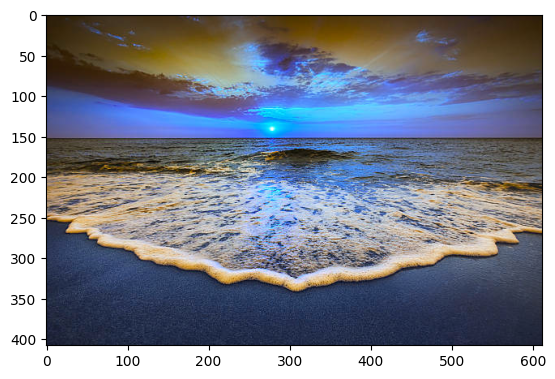

In [63]:
plt.imshow(img)

In [64]:
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img[0]

array([[ 9, 28, 43],
       [ 9, 28, 43],
       [10, 29, 44],
       ...,
       [11, 30, 45],
       [11, 30, 45],
       [11, 30, 45]], shape=(612, 3), dtype=uint8)

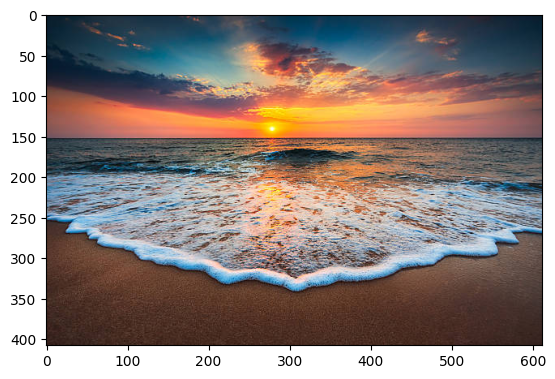

In [65]:

plt.imshow(img)

In [66]:
def read_img(path_to_img):
    img = cv2.imread(path_to_img) #! read the input img
    
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) #! Convert the img from BGR to RGB
    
    img = img / 255.0 #! Normalize the img vecs
    
    return img

In [67]:
def initialize_centroids(img, clusters):
    points = img.reshape((-1, img.shape[2]))
    m, n = points.shape

    means = np.zeros((clusters, n))

    for i in range(clusters):
        rand_idxes = np.random.choice(m, size=10, replace=False)
        means[i] = np.mean(points[rand_idxes], axis=0)

    return points, means

In [68]:
def euclidian_distance(p1, p2):
    return np.sqrt(np.sum(np.square(p2 - p1)))

In [69]:
def k_means(points, centroid_means, clusters):
    iterations = 10
    m, n = points.shape
    
    index = np.zeros(m, dtype=int)
    
    while iterations > 0:
        for j in range(m):
            min_dist = float('inf')
            best_cluster = 0
            
            for k in range(clusters):
                dist = euclidian_distance(points[j], centroid_means[k])

                if  dist < min_dist:
                    min_dist = dist 
                    best_cluster = k
            index[j] = best_cluster
                    
        for k in range(clusters):
            cluster_points = points[index == k]
            
            if len(cluster_points) > 0:
                centroid_means[k] = np.mean(cluster_points, axis=0)
                
        iterations -= 1

    return centroid_means, index

In [70]:
def compress_img(centroid_means, index, img):
    centroid = np.array(centroid_means)
    
    recovered = centroid[index.astype(int), :]
    
    recovered = recovered.reshape(img.shape)
    
    plt.imshow(recovered)
    plt.show()
    
    return recovered

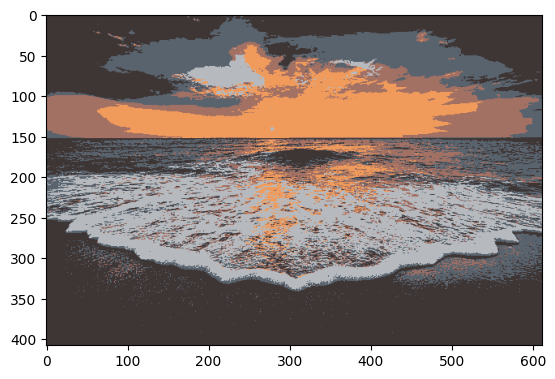

In [76]:
# Driver Code
clusters = 5

img = read_img(img_path)

points, means = initialize_centroids(img, clusters)
means, index = k_means(points, means, clusters)
new_img = compress_img(means, index, img)

In [77]:
points[0]

array([0.03529412, 0.10980392, 0.16862745])

In [78]:
# Original image size (in bytes)
original_size = img.nbytes

# Compressed size:
# centroids + index array
compressed_size = means.nbytes + index.nbytes

print(f"Original size (bytes): {original_size:,}")
print(f"Compressed size (bytes): {compressed_size:,}")
print(f"Compression ratio: {(original_size / compressed_size):.3f}")

Original size (bytes): 5,992,704
Compressed size (bytes): 1,997,688
Compression ratio: 3.000


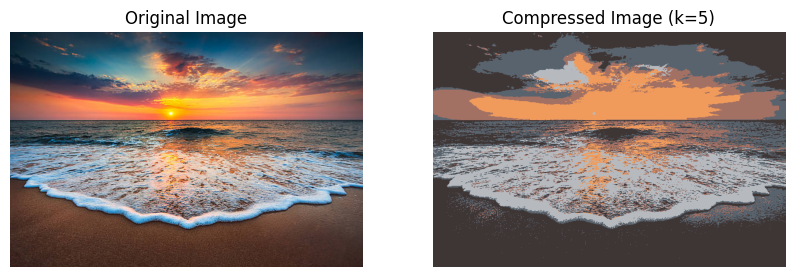

In [79]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.title("Original Image")
plt.imshow(img)
plt.axis('off')

plt.subplot(1,2,2)
plt.title(f"Compressed Image (k={clusters})")
plt.imshow(new_img)
plt.axis('off')

plt.show()